### Data preprocessing

In [1]:
from pathlib import Path
import random
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm

import torch
from facenet_pytorch import MTCNN

/home/sera/Projects/image_emotion_detection/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
SEED = 64
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
source = Path("../data/dataset_pre")                 # has train/ and test/ inside
target = Path("../data/dataset_processed_split")     # will be created

# Splits
splits = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
}

# Preprocessing settings
OUT_SIZE = 128         # final resolution (ConvNeXt-friendly; also fine for ViT-S)
MARGIN = 0.30          # crop margin around face box
USE_CLAHE = True       # illumination normalization


In [3]:
assert abs(sum(splits.values()) - 1.0) < 1e-9, "Splits must sum to 1.0"
assert (source / "train").exists(), "Expected source/train"
assert (source / "test").exists(), "Expected source/test"

target.mkdir(parents=True, exist_ok=True)
print("Source:", source.resolve())
print("Target:", target.resolve())


Source: /home/sera/Projects/image_emotion_detection/data/dataset_pre
Target: /home/sera/Projects/image_emotion_detection/data/dataset_processed_split


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

mtcnn = MTCNN(
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=False,
    device=device,
    keep_all=True
)


Device: cuda


In [5]:
# Merge all image paths from source/train and source/test into a dict per class
all_images = {}

for split_name in ["train", "test"]:
    split_dir = source / split_name
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        all_images.setdefault(class_dir.name, [])
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() == ".png":
                all_images[class_dir.name].append(img_path)

# Summary
total = 0
for cls, imgs in sorted(all_images.items()):
    print(f"{cls:>12}: {len(imgs)}")
    total += len(imgs)
print("Total images:", total)

assert total > 0, "No images found. Check paths."


       angry: 4953
   disgusted: 547
     fearful: 5121
       happy: 8989
     neutral: 6198
         sad: 6077
   surprised: 4002
Total images: 35887


In [6]:
split_paths = {"train": {}, "val": {}, "test": {}}

for class_name, images in all_images.items():
    images = list(images)  # copy
    random.shuffle(images)

    n = len(images)
    n_train = int(n * splits["train"])
    n_val = int(n * splits["val"])
    # remainder goes to test

    split_images = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:]
    }

    for split_name, imgs in split_images.items():
        split_paths[split_name][class_name] = imgs

# Verify counts match
for split_name in ["train", "val", "test"]:
    count = sum(len(split_paths[split_name][c]) for c in split_paths[split_name])
    print(f"{split_name:>5}: {count}")


train: 25117
  val: 5380
 test: 5390


In [7]:
def clamp_box(box, w, h):
    x1, y1, x2, y2 = box
    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w - 1, x2))
    y2 = max(0, min(h - 1, y2))
    if x2 <= x1: x2 = min(w - 1, x1 + 1)
    if y2 <= y1: y2 = min(h - 1, y1 + 1)
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def expand_box(box, w, h, margin=0.3):
    x1, y1, x2, y2 = box.astype(np.float32)
    bw = x2 - x1
    bh = y2 - y1
    x1 -= bw * margin
    y1 -= bh * margin
    x2 += bw * margin
    y2 += bh * margin
    return clamp_box([x1, y1, x2, y2], w, h)

def apply_clahe_gray(gray_u8):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_u8)

def to_gray_u8(pil_img):
    arr = np.array(pil_img.convert("L"))
    if arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)
    return arr


In [8]:
def align_by_eyes(gray, landmarks, out_size=128):
    """
    gray: HxW uint8 (cropped region)
    landmarks: (5,2) float in crop coords: left_eye, right_eye, nose, mouth_left, mouth_right
    """
    if landmarks is None or len(landmarks) != 5:
        return cv2.resize(gray, (out_size, out_size), interpolation=cv2.INTER_CUBIC)

    left_eye = landmarks[0]
    right_eye = landmarks[1]

    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    eyes_center = ((left_eye[0] + right_eye[0]) / 2.0, (left_eye[1] + right_eye[1]) / 2.0)
    h, w = gray.shape[:2]
    M = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)

    rotated = cv2.warpAffine(
        gray, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    # rotate landmarks too (for a stable crop)
    ones = np.ones((5, 1), dtype=np.float32)
    pts = np.hstack([landmarks.astype(np.float32), ones])  # 5x3
    rot_pts = (M @ pts.T).T  # 5x2

    nose = rot_pts[2]
    cx, cy = float(nose[0]), float(nose[1])

    eye_dist = float(np.linalg.norm(rot_pts[1] - rot_pts[0]))
    crop_half = max(out_size * 0.6, eye_dist * 1.8)  # heuristic

    x1 = int(cx - crop_half); y1 = int(cy - crop_half)
    x2 = int(cx + crop_half); y2 = int(cy + crop_half)

    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(w, x2); y2 = min(h, y2)

    face = rotated[y1:y2, x1:x2]
    if face.size == 0:
        face = rotated

    return cv2.resize(face, (out_size, out_size), interpolation=cv2.INTER_CUBIC)


def preprocess_image(path, out_size=128, margin=0.3, use_clahe=True):
    """
    Returns a processed grayscale face image (uint8, out_size x out_size).
    Never drops the sample: falls back to simple resize if detection fails.
    """
    pil = Image.open(path).convert("RGB")
    w, h = pil.size
    gray = to_gray_u8(pil)

    boxes, probs, landmarks = mtcnn.detect(pil, landmarks=True)

    if boxes is None or len(boxes) == 0:
        face = cv2.resize(gray, (out_size, out_size), interpolation=cv2.INTER_CUBIC)
        detected = False
    else:
        best_i = int(np.argmax(probs))
        box = clamp_box(boxes[best_i], w, h)
        box = expand_box(box, w, h, margin=margin)

        x1, y1, x2, y2 = box.astype(int)
        crop_gray = gray[y1:y2, x1:x2]

        # shift landmarks into crop coordinates
        lm = landmarks[best_i].copy()
        lm[:, 0] -= x1
        lm[:, 1] -= y1

        face = align_by_eyes(crop_gray, lm, out_size=out_size)
        detected = True

    if use_clahe:
        face = apply_clahe_gray(face)

    return face, detected


In [9]:
# Stats
stats = {
    "train": {"total": 0, "detected": 0},
    "val":   {"total": 0, "detected": 0},
    "test":  {"total": 0, "detected": 0},
}

for split_name in ["train", "val", "test"]:
    for class_name, img_list in split_paths[split_name].items():
        out_dir = target / split_name / class_name
        out_dir.mkdir(parents=True, exist_ok=True)

        for img_path in tqdm(img_list, desc=f"{split_name}/{class_name}", leave=False):
            face, detected = preprocess_image(
                img_path,
                out_size=OUT_SIZE,
                margin=MARGIN,
                use_clahe=USE_CLAHE
            )

            out_path = out_dir / img_path.name
            cv2.imwrite(str(out_path), face)

            stats[split_name]["total"] += 1
            stats[split_name]["detected"] += int(detected)

print("Done.")


KeyboardInterrupt: 

In [11]:
for split_name in ["train", "val", "test"]:
    total = stats[split_name]["total"]
    det = stats[split_name]["detected"]
    rate = (det / total * 100.0) if total else 0.0
    print(f"{split_name:>5}: detected {det}/{total} ({rate:.2f}%)")


train: detected 4032/5198 (77.57%)
  val: detected 0/0 (0.00%)
 test: detected 0/0 (0.00%)


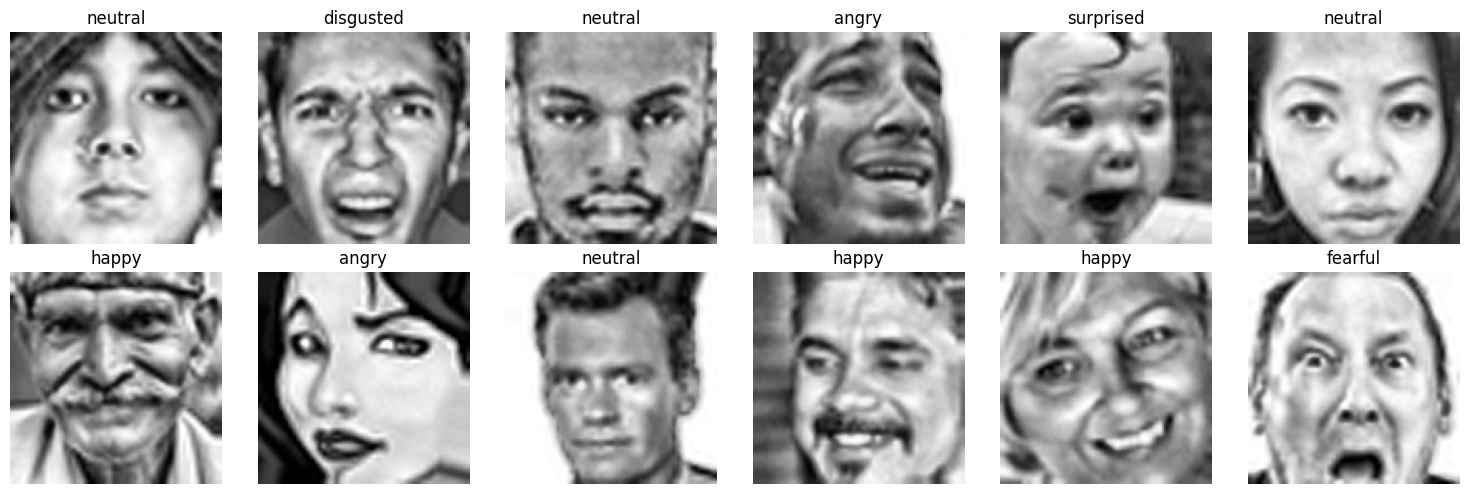

In [12]:
import matplotlib.pyplot as plt

def show_random_processed(split_name="train", n=12):
    # pick random class and images from processed folder
    split_dir = target / split_name
    classes = [d for d in split_dir.iterdir() if d.is_dir()]
    if not classes:
        print("No processed images found.")
        return

    samples = []
    for _ in range(n):
        cls = random.choice(classes)
        imgs = list(cls.glob("*.png"))
        if imgs:
            samples.append(random.choice(imgs))

    cols = 6
    rows = int(np.ceil(len(samples) / cols))
    plt.figure(figsize=(cols * 2.5, rows * 2.5))

    for i, p in enumerate(samples, 1):
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray")
        plt.title(f"{p.parent.name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_processed("train", n=12)
